# TASK 1: Data gathering and exploratory analysis

# Step 1: IMPORT LIBRARIES AND DATASETS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
# loading the dataset
demographics = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Customer_Demographics")
transactions = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Transaction_History")
service = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Customer_Service")
activity = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Online_Activity")
churn = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name="Churn_Status")

In [3]:
demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [4]:
transactions.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [5]:
service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [6]:
activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [7]:
churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


# Step 2: Merge the Tables

### All tables have CustomerID, so we combine them.

In [8]:
df = demographics.merge(activity, on="CustomerID")
df = df.merge(churn, on="CustomerID")

### For transactions and service we usually aggregate because customers have multiple records.

In [9]:
transactions_summary = transactions.groupby("CustomerID")["AmountSpent"].sum().reset_index()

df = df.merge(transactions_summary, on="CustomerID")

# Step 3: Exploratory Data Analysis

In [10]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,AmountSpent
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,0,416.50
1,2,65,M,Married,Low,2023-12-05,5,Website,1,1547.42
2,3,18,M,Single,Low,2023-11-15,3,Website,0,1702.98
3,4,21,M,Widowed,Low,2023-08-25,2,Website,0,917.29
4,5,21,M,Divorced,Medium,2023-10-27,41,Website,0,2001.49


In [11]:
df.tail()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,AmountSpent
995,996,54,F,Single,Low,2023-01-29,38,Mobile App,0,227.25
996,997,19,M,Widowed,High,2023-04-01,5,Mobile App,0,419.82
997,998,47,M,Married,Low,2023-07-10,47,Website,0,252.15
998,999,23,M,Widowed,High,2023-01-08,23,Website,0,2393.26
999,1000,34,M,Widowed,Low,2023-08-13,22,Mobile App,0,1670.79


In [12]:
df.shape

(1000, 10)

In [13]:
df.describe()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,AmountSpent
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.267000,2023-07-05 21:28:48,25.912000,0.204000,1267.074950
min,1.000000,18.000000,2023-01-01 00:00:00,1.000000,0.000000,9.800000
25%,250.750000,30.000000,2023-04-08 00:00:00,13.750000,0.000000,626.685000
50%,500.500000,43.000000,2023-07-10 12:00:00,27.000000,0.000000,1232.880000
75%,750.250000,56.000000,2023-10-01 06:00:00,38.000000,0.000000,1791.902500
max,1000.000000,69.000000,2023-12-31 00:00:00,49.000000,1.000000,3386.040000
std,288.819436,15.242311,NaN,14.055953,0.403171,738.590013


### Histogram (Age Distribution)

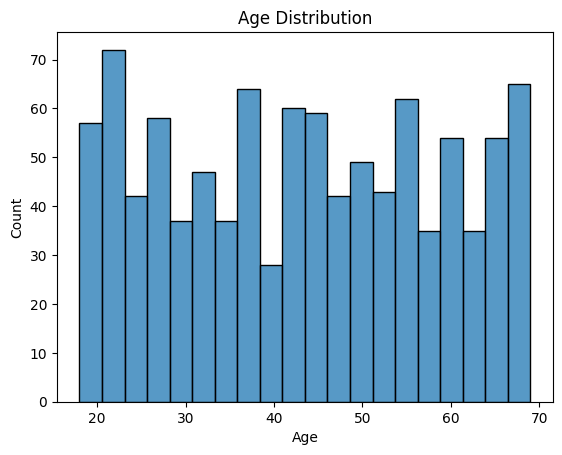

In [14]:
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

### Boxplot (Outliers)

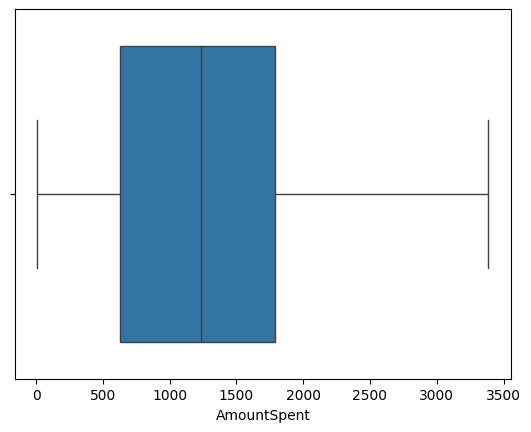

In [15]:
sns.boxplot(x=df["AmountSpent"])
plt.show()

### Customers with low login frequency show higher churn probability.

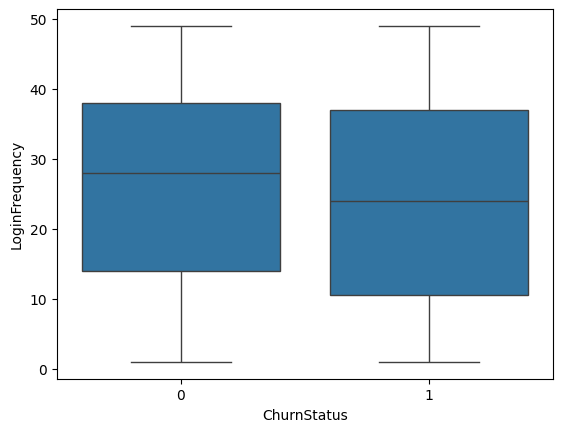

In [16]:
sns.boxplot(x="ChurnStatus", y="LoginFrequency", data=df)
plt.show()

### Correlation Heatmap

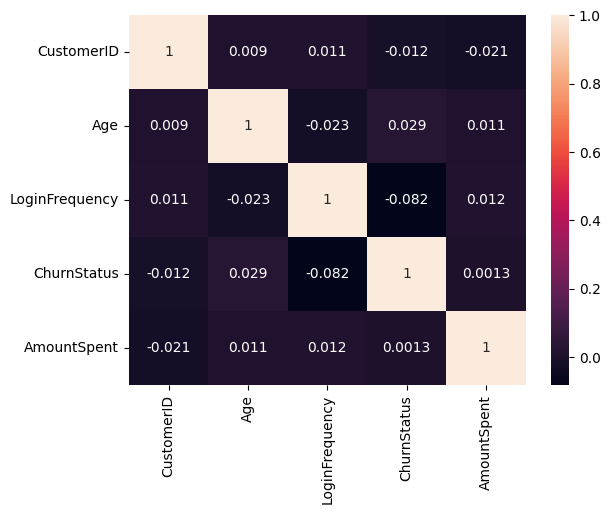

In [17]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

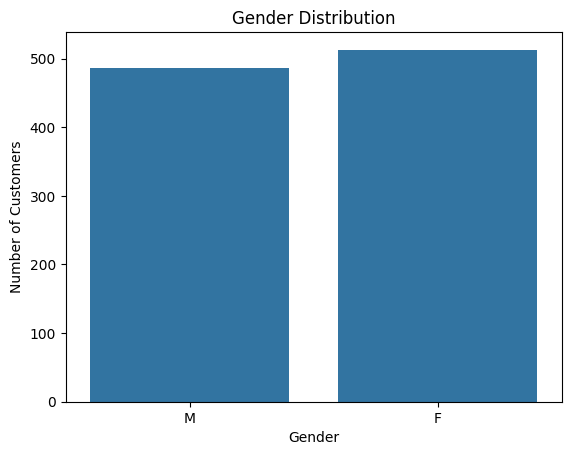

In [18]:
sns.countplot(x="Gender", data=demographics)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

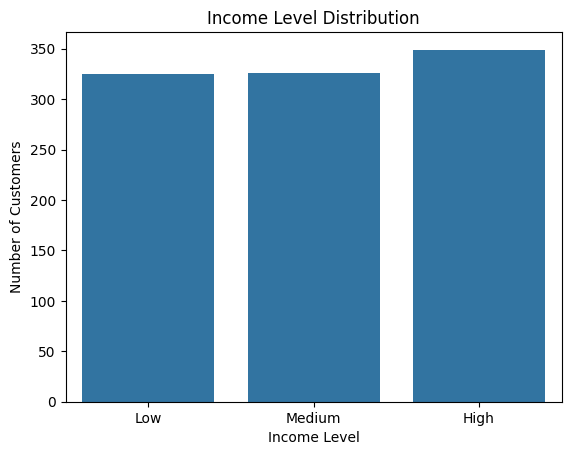

In [19]:
sns.countplot(x="IncomeLevel", data=demographics)
plt.title("Income Level Distribution")
plt.xlabel("Income Level")
plt.ylabel("Number of Customers")
plt.show()

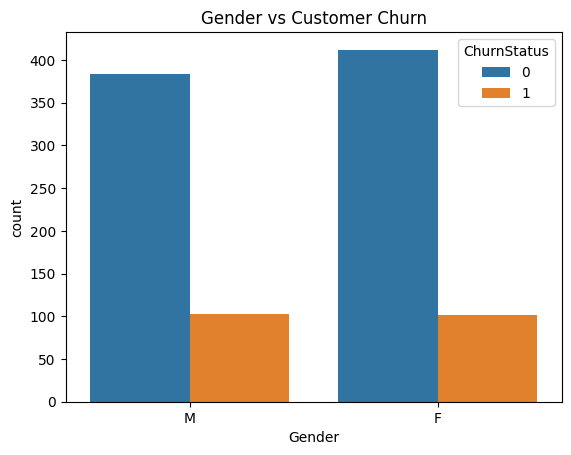

In [20]:
sns.countplot(x="Gender", hue="ChurnStatus", data=df)
plt.title("Gender vs Customer Churn")
plt.show()

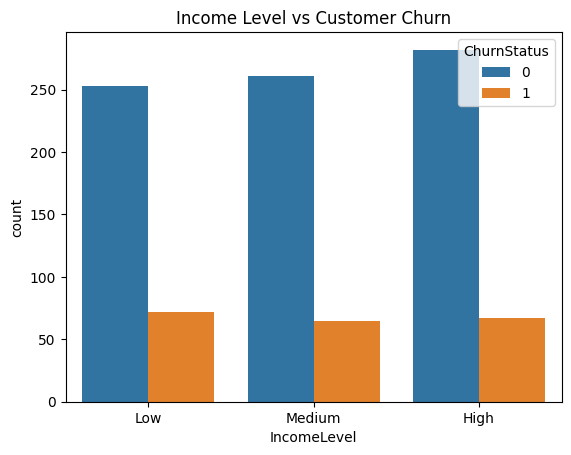

In [21]:
sns.countplot(x="IncomeLevel", hue="ChurnStatus", data=df)
plt.title("Income Level vs Customer Churn")
plt.show()

# Step 4: Data Cleaning

In [22]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
MaritalStatus     0
IncomeLevel       0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
ChurnStatus       0
AmountSpent       0
dtype: int64

### There are no missing values in this data set

# Step 5: Encode Categorical Variables

In [23]:
df = pd.get_dummies(df, drop_first=True)

# Step 6: Standardization

In [24]:
scaler = StandardScaler()

df["Age"] = scaler.fit_transform(df[["Age"]])
df["AmountSpent"] = scaler.fit_transform(df[["AmountSpent"]])

# Step 7: Now Dataset is Ready For Machine Learning Models

In [26]:
df.head()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,AmountSpent,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,1.229628,2023-10-21,34,0,-1.152196,True,False,True,False,True,False,False,False
1,2,1.426547,2023-12-05,5,1,0.379758,True,True,False,False,True,False,False,True
2,3,-1.658518,2023-11-15,3,0,0.590481,True,False,True,False,True,False,False,True
3,4,-1.461599,2023-08-25,2,0,-0.473822,True,False,False,True,True,False,False,True
4,5,-1.461599,2023-10-27,41,0,0.994845,True,False,False,False,False,True,False,True


# Step 8: IMPORT LIBRARIES AND DATASETS For Task2

In [27]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [28]:
df.head()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,AmountSpent,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,1.229628,2023-10-21,34,0,-1.152196,True,False,True,False,True,False,False,False
1,2,1.426547,2023-12-05,5,1,0.379758,True,True,False,False,True,False,False,True
2,3,-1.658518,2023-11-15,3,0,0.590481,True,False,True,False,True,False,False,True
3,4,-1.461599,2023-08-25,2,0,-0.473822,True,False,False,True,True,False,False,True
4,5,-1.461599,2023-10-27,41,0,0.994845,True,False,False,False,False,True,False,True


# Step 9: Define Features and Target

In [30]:
df = df.drop("CustomerID", axis=1)

In [31]:
X = df.drop("ChurnStatus", axis=1)
y = df["ChurnStatus"]

In [35]:
X = X.select_dtypes(exclude=['datetime64'])

# Step 10: Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 11: Train Logistic Regression Model

In [37]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Step 12: Make Predictions

In [38]:
y_pred = model.predict(X_test)

In [39]:
y_prob = model.predict_proba(X_test)[:,1]

# Step 13: Model Accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.75


# Step 14: Confusion Matrix

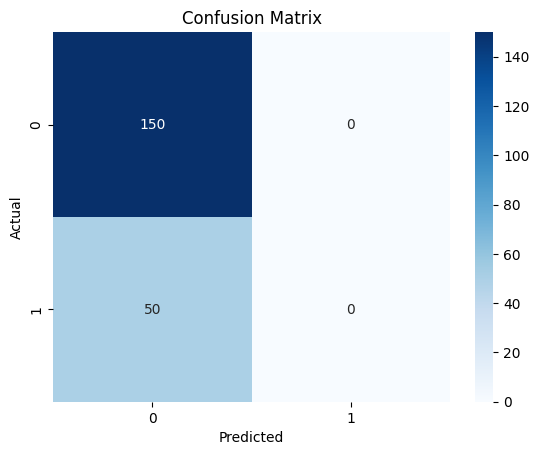

In [41]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Step 15: Classification Report

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86       150
           1       0.00      0.00      0.00        50

    accuracy                           0.75       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.56      0.75      0.64       200



C:\Users\sahil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sahil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sahil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

# Step 16: ROC AUC Score

In [43]:
roc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc_score)

ROC AUC Score: 0.4845333333333333


# Step 17: ROC Curve

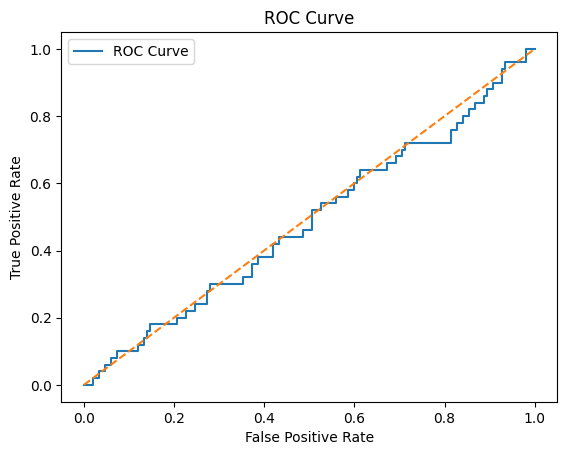

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Step 18: Feature Importance

In [45]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance

,Feature,Coefficient
4,MaritalStatus_Married,0.196219
7,IncomeLevel_Low,0.154037
0,Age,0.125355
3,Gender_M,0.095512
8,IncomeLevel_Medium,0.076947
2,AmountSpent,0.062577
5,MaritalStatus_Single,0.061852
6,MaritalStatus_Widowed,0.015265
9,ServiceUsage_Online Banking,0.008338
1,LoginFrequency,-0.022056


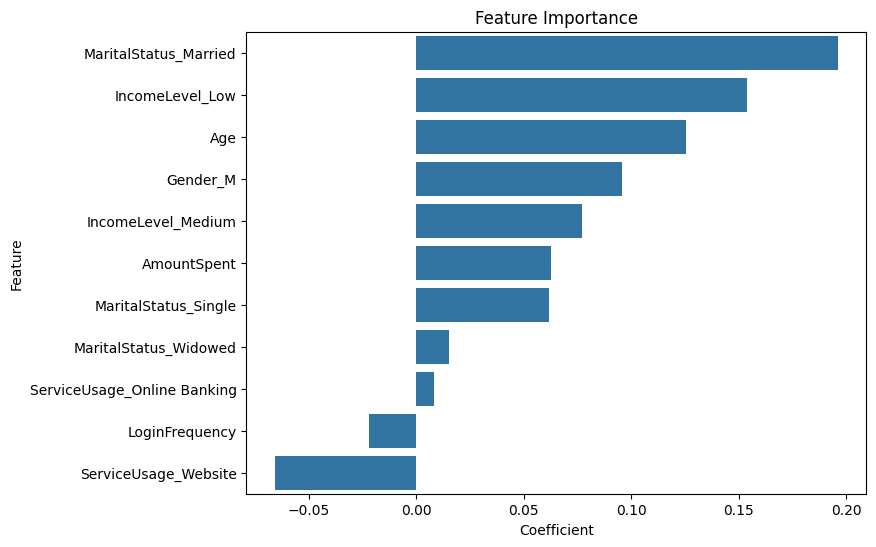

In [46]:
plt.figure(figsize=(8,6))

sns.barplot(x="Coefficient", y="Feature", data=feature_importance)

plt.title("Feature Importance")

plt.show()

# Step 19 — Save Model

In [48]:
import joblib
joblib.dump(model, "churn_prediction_model.pkl")

['churn_prediction_model.pkl']